# =====================================================
# CUSTOMER INSIGHTS - STATISTICAL INVESTIGATION
## Career247 Data Analytics with GenAI Project
# =====================================================

In [156]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind
import statsmodels.api as sm
from statsmodels.formula.api import ols

## STEP 1 - Data Loading & Understanding the Data Structure

### Data Loading

In [157]:
df=pd.read_csv("US_Customer_Insights_Dataset.csv")
df.head()

,CustomerID,Name,State,Education,Gender,Age,Married,NumPets,JoinDate,TransactionDate,MonthlySpend,DaysSinceLastInteraction
0,CUST10319,Scott Perez,Florida,High School,Non-Binary,47,Yes,1,9/19/21,9/2/24,1281.74,332
1,CUST10695,Jennifer Burton,Washington,Master,Male,72,Yes,0,4/5/24,6/2/24,429.46,424
2,CUST10297,Michelle Rogers,Arizona,Master,Female,40,Yes,2,7/24/24,2/28/25,510.34,153
3,CUST10103,Brooke Hendricks,Texas,Master,Male,27,Yes,0,8/12/23,3/29/25,396.47,124
4,CUST10219,Karen Johns,Texas,High School,Female,28,Yes,1,12/6/21,7/24/22,139.68,1103


### Understanding the Data Structure

In [158]:
print ("SHAPE & STRUCTURE:")
print(f"Rows x Columns: {df.shape}")
print(f"Unique Customers: {df["CustomerID"].nunique()}")
print("\nALL COLUMNS:", df.columns.tolist())
print("\nMISSING VALUES:\n", df.isnull().sum())
print("\nDATA TYPES:\n", df.dtypes)
print("\nFULL DATA SUMMARY:")
df.info()

SHAPE & STRUCTURE:
Rows x Columns: (10675, 12)
Unique Customers: 1000

ALL COLUMNS: ['CustomerID', 'Name', 'State', 'Education', 'Gender', 'Age', 'Married', 'NumPets', 'JoinDate', 'TransactionDate', 'MonthlySpend', 'DaysSinceLastInteraction']

MISSING VALUES:
 CustomerID                  0
Name                        0
State                       0
Education                   0
Gender                      0
Age                         0
Married                     0
NumPets                     0
JoinDate                    0
TransactionDate             0
MonthlySpend                0
DaysSinceLastInteraction    0
dtype: int64

DATA TYPES:
 CustomerID                   object
Name                         object
State                        object
Education                    object
Gender                       object
Age                           int64
Married                      object
NumPets                       int64
JoinDate                     object
TransactionDate             

In [159]:
df["JoinDate"]=pd.to_datetime(df["JoinDate"])
df["TransactionDate"]=pd.to_datetime(df["TransactionDate"])
print("\nDATA TYPES:\n", df.dtypes)
import warnings
warnings.filterwarnings("ignore")


DATA TYPES:
 CustomerID                          object
Name                                object
State                               object
Education                           object
Gender                              object
Age                                  int64
Married                             object
NumPets                              int64
JoinDate                    datetime64[ns]
TransactionDate             datetime64[ns]
MonthlySpend                       float64
DaysSinceLastInteraction             int64
dtype: object


## STEP 2 - Descriptive Statistics

In [160]:
numeric_cols = ["Age", "NumPets", "MonthlySpend", "DaysSinceLastInteraction"]
cat_cols = ["State", "Education", "Gender", "Married"]

# Numeric summary
print("\nNUMERICAL VARIABLES SUMMARY:\n")
desc_num = df[numeric_cols].describe()
print(desc_num)

# Categorical modes
print("\nCATEGORICAL MODES (MOST COMMON VALUE IN EACH):\n")
print("State mode:", df['State'].mode()[0])
print("Education mode:", df['Education'].mode()[0])
print("Gender mode:", df['Gender'].mode()[0])
print("Married mode:", df['Married'].mode()[0])


NUMERICAL VARIABLES SUMMARY:

                Age       NumPets  MonthlySpend  DaysSinceLastInteraction
count  10675.000000  10675.000000  10675.000000              10675.000000
mean      49.474567      1.340515    331.610315                538.469883
std       18.221365      1.150849    225.799253                398.766747
min       18.000000      0.000000      3.890000                  1.000000
25%       35.000000      0.000000    165.495000                218.000000
50%       49.000000      1.000000    282.110000                445.000000
75%       66.000000      2.000000    443.255000                788.500000
max       80.000000      4.000000   1740.420000               1791.000000

CATEGORICAL MODES (MOST COMMON VALUE IN EACH):

State mode: California
Education mode: Master
Gender mode: Male
Married mode: No


## STEP 3 - Data Visualizations

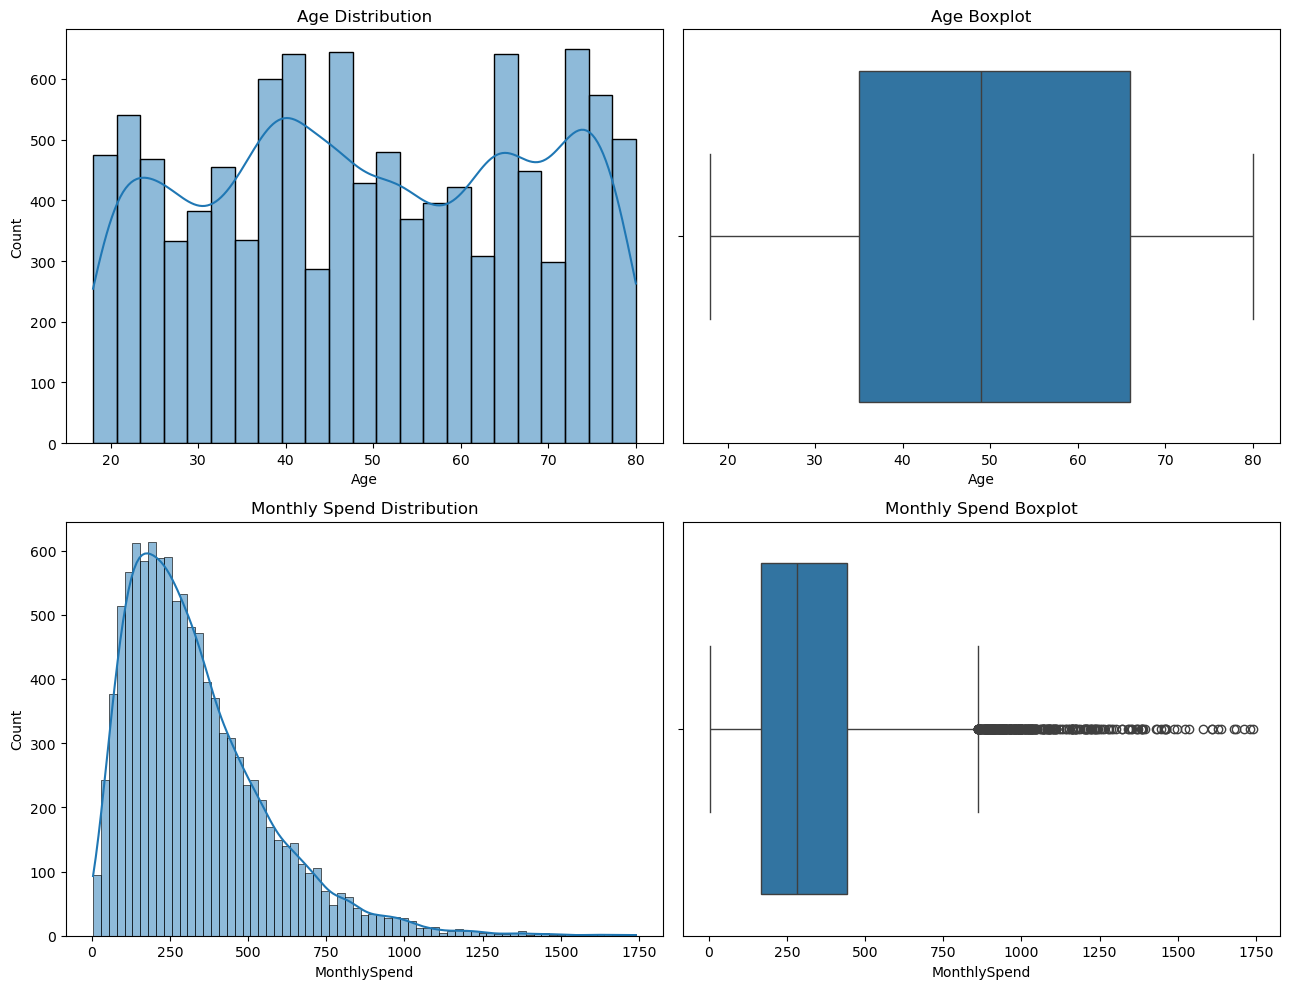

In [161]:
# 3.1 - Plotting histograms and boxplots
fig,axes = plt.subplots(2,2, figsize=(13,10))

sns.histplot(df["Age"], kde=True, ax=axes[0,0])
axes[0,0].set_title("Age Distribution")

sns.boxplot(x=df["Age"], ax=axes[0,1])
axes[0,1].set_title("Age Boxplot")

sns.histplot(df["MonthlySpend"], kde=True, ax=axes[1,0])
axes[1,0].set_title("Monthly Spend Distribution")

sns.boxplot(x=df["MonthlySpend"], ax=axes[1,1])
axes[1,1].set_title("Monthly Spend Boxplot")

plt.tight_layout()
plt.show()

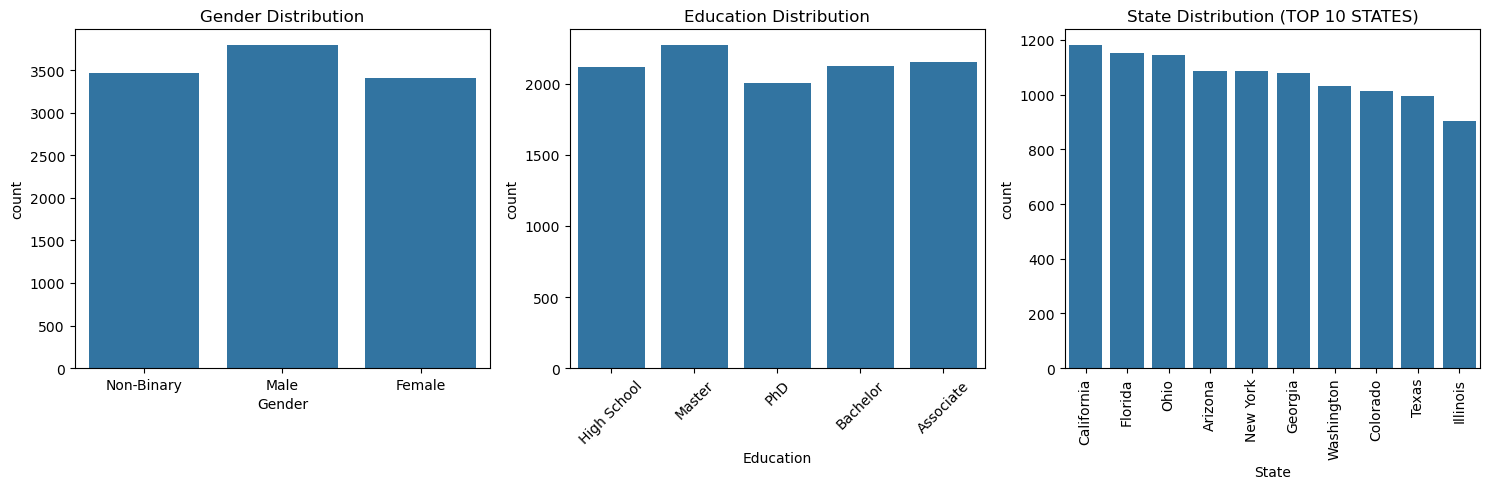

In [162]:
# 3.2 - Creating bar charts for Categories (Gender, Education, State)
fig, axes = plt.subplots(1,3, figsize=(15,5))

sns.countplot(data=df, x="Gender", ax=axes[0])
axes[0].set_title("Gender Distribution")

sns.countplot(data=df, x="Education", ax=axes[1])
axes[1].set_title("Education Distribution")
axes[1].tick_params(axis="x", rotation=45)

sns.countplot(data=df, x="State", order=df["State"].value_counts().index[:10], ax=axes[2])
axes[2].set_title("State Distribution (TOP 10 STATES)")
axes[2].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

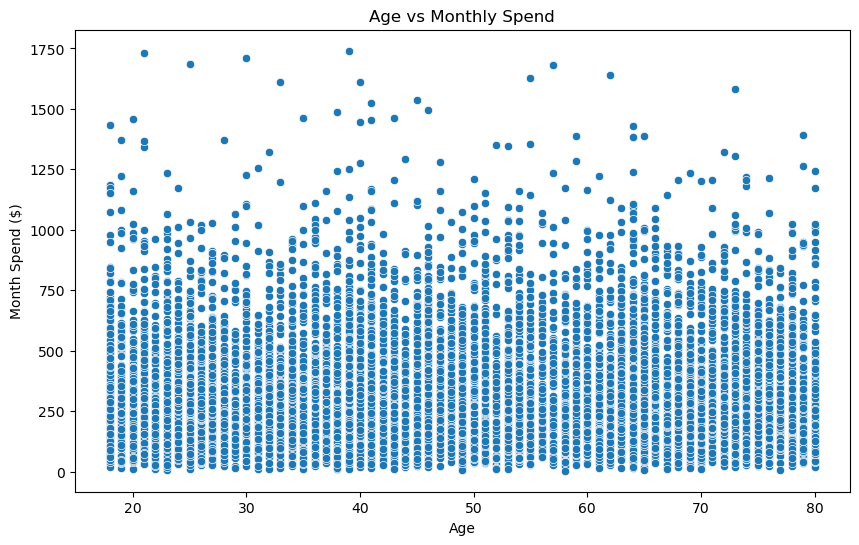

In [163]:
# 3.3 - Creating Scatterplot: Age vs MonthlySpend
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Age", y="MonthlySpend")
plt.title("Age vs Monthly Spend")
plt.xlabel("Age")
plt.ylabel("Month Spend ($)")
plt.show()

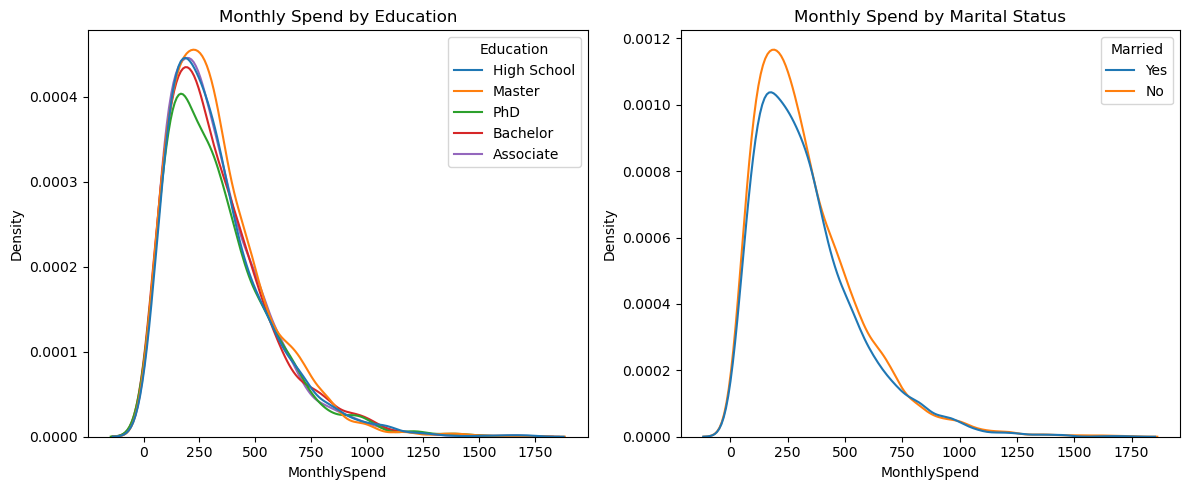

In [164]:
# 3.4 - Kde plots: Spending behavior by education level or marital status
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# LEFT: Education
sns.kdeplot(data=df, x="MonthlySpend", hue="Education", ax=ax1)
ax1.set_title("Monthly Spend by Education")

# RIGHT: Married  
sns.kdeplot(data=df, x="MonthlySpend", hue="Married", ax=ax2)
ax2.set_title("Monthly Spend by Marital Status")

plt.tight_layout()
plt.show()

## STEP 4 - Bivariate Analysis

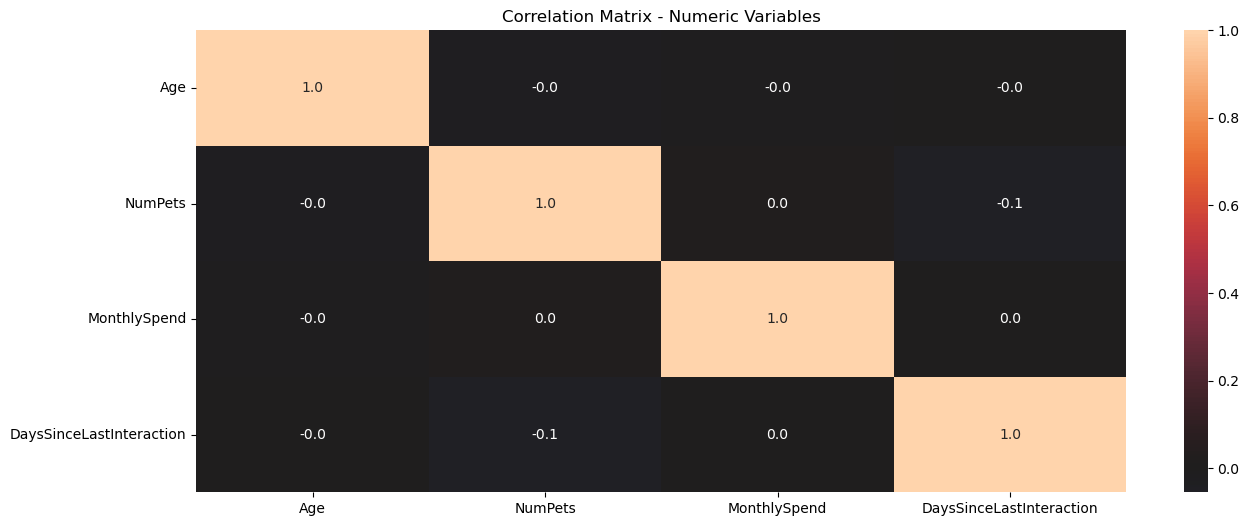

In [165]:
# 4.1 - Correlation Matrix
plt.figure(figsize=(15,6))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".1f", center=0)
plt.title("Correlation Matrix - Numeric Variables")
plt.show()
    

In [166]:
# 4.2 - Crosstab (Gender vs Married)
print ("4.2 GENDER VS MARRIED CROSSTAB:\n")
print (pd.crosstab(df["Gender"],df["Married"], margins=True))

4.2 GENDER VS MARRIED CROSSTAB:

Married       No   Yes    All
Gender                       
Female      1797  1616   3413
Male        1892  1899   3791
Non-Binary  1894  1577   3471
All         5583  5092  10675


In [167]:
# 4.3 - Grouped Averages
print("AVERAGE MONTHLY SPEND BY CATEGORY:")

avg_state=df.groupby("State")["MonthlySpend"].agg(["mean","count"]).round(2)
print("\nBy State:\n", avg_state.sort_values("mean", ascending=False))

avg_edu=df.groupby("Education")["MonthlySpend"].agg(["mean","count"]).round(2)
print("\nBy Education:\n", avg_edu.sort_values("mean", ascending=False))

avg_gender=df.groupby("Gender")["MonthlySpend"].agg(["mean","count"]).round(2)
print("\nBy Gender:\n", avg_gender)

AVERAGE MONTHLY SPEND BY CATEGORY:

By State:
               mean  count
State                    
Arizona     341.49   1087
Ohio        340.19   1145
California  339.18   1180
Illinois    332.59    905
New York    332.15   1085
Washington  329.44   1030
Georgia     328.35   1080
Florida     327.70   1152
Colorado    323.08   1014
Texas       319.51    997

By Education:
                mean  count
Education                 
Master       334.25   2269
High School  332.22   2120
Bachelor     331.88   2127
PhD          331.69   2006
Associate    327.88   2153

By Gender:
               mean  count
Gender                   
Female      331.36   3413
Male        333.17   3791
Non-Binary  330.15   3471


## STEP 5&6 - Formulate Hypotheses & Statistical Tests

## T-TEST HYPOTHESIS

**H₀ (Null Hypothesis):** No significant difference in monthly spend between Male & Female customers  
**H₁ (Alternative Hypothesis):** Significant difference exists in monthly spend between genders  
**Significance Level:** α = 0.05  
**Test:** Independent 2-sample t-test


In [176]:
# 5.1 - T-Test: Male vs Female Monthly Spend
male_spend = df[df["Gender"] == "Male"]["MonthlySpend"].dropna()
female_spend = df[df["Gender"] == "Female"]["MonthlySpend"].dropna()

t_stat, p_ttest = stats.ttest_ind(male_spend, female_spend, equal_var=False)
print("5.1 T-TEST RESULTS:")
print(f"p-value: {p_ttest:.2f}")
print("Interpretation: " + ("Significant difference" if p_ttest < 0.05 else "No significant difference"))

5.1 T-TEST RESULTS:
p-value: 0.73
Interpretation: No significant difference


## ANOVA EDUCATION HYPOTHESIS

**H₀ (Null Hypothesis):** All education levels have the same mean monthly spend  
**H₁ (Alternative Hypothesis):** At least one education level has different mean monthly spend  
**Significance Level:** α = 0.05  
**Test:** One-way ANOVA


In [169]:
# 5.2 ANOVA: Education vs Monthly Spend
model_edu = ols("MonthlySpend ~ C(Education)", data=df).fit()
anova_edu = sm.stats.anova_lm(model_edu, typ=2)
print("5.2 ANOVA EDUCATION RESULTS:")
print(anova_edu)
print(f"Education p-value: {anova_edu['PR(>F)']['C(Education)']:.4f}")

5.2 ANOVA EDUCATION RESULTS:
                    sum_sq       df         F    PR(>F)
C(Education)  4.667660e+04      4.0  0.228807  0.922359
Residual      5.441704e+08  10670.0       NaN       NaN
Education p-value: 0.9224


## CHI-SQUARE HYPOTHESIS

**H₀ (Null Hypothesis):** No association between marital status and number of pets  
**H₁ (Alternative Hypothesis):** Significant association exists between marital status and pets  
**Significance Level:** α = 0.05  
**Test:** Chi-square test of independence


In [174]:
# 5.3 - Create crosstab
crosstab = pd.crosstab(df['Married'], df['NumPets'])
chi2, p_chi, dof, expected = stats.chi2_contingency(crosstab)

print("5.3 CHI-SQUARE RESULTS:")
print(f"Crosstab:\n", crosstab)
print(f"Chi2 = {chi2:.2f}, p-value = {p_chi:.4f}")
print("Interpretation: " + ("SIGNIFICANT ASSOCIATION" if p_chi < 0.05 else "NO ASSOCIATION"))

5.3 CHI-SQUARE RESULTS:
Crosstab:
 NumPets     0     1     2    3    4
Married                            
No       1839  1435  1504  509  296
Yes      1205  1770  1242  598  277
Chi2 = 177.64, p-value = 0.0000
Interpretation: SIGNIFICANT ASSOCIATION


## CORRELATION HYPOTHESIS

**H₀ (Null Hypothesis):** No significant correlation between Age and Days Since Last Interaction (ρ = 0)  
**H₁ (Alternative Hypothesis):** Significant correlation exists (ρ ≠ 0)  
**Significance Level:** α = 0.05  
**Test:** Pearson correlation coefficient


In [171]:
# 5.4 - Correlation: Age vs DaysSinceLastInteraction
corr_coef, p_corr = stats.pearsonr(
    df["Age"].dropna(), 
    df["DaysSinceLastInteraction"].dropna()
)
print("5.4 CORRELATION RESULTS:")
print(f"Correlation: {corr_coef:.4f}, p-value: {p_corr:.4f}")
print("Interpretation: " + ("Significant correlation" if p_corr < 0.05 else "No significant correlation"))

5.4 CORRELATION RESULTS:
Correlation: -0.0040, p-value: 0.6817
Interpretation: No significant correlation


## STATE ANOVA HYPOTHESIS

**H₀ (Null Hypothesis):** All states have the same mean monthly spend  
**H₁ (Alternative Hypothesis):** At least one state has different mean monthly spend  
**Significance Level:** α = 0.05  
**Test:** One-way ANOVA


In [172]:
# 5.5 ANOVA: State vs Monthly Spend
model_state = ols("MonthlySpend ~ C(State)", data=df).fit()
anova_state = sm.stats.anova_lm(model_state, typ=2)
print("5.5 ANOVA STATE RESULTS:")
print(anova_state)
print(f"State p-value: {anova_state['PR(>F)']['C(State)']:.4f}")


5.5 ANOVA STATE RESULTS:
                sum_sq       df         F    PR(>F)
C(State)  5.128908e+05      9.0  1.117842  0.345719
Residual  5.437042e+08  10665.0       NaN       NaN
State p-value: 0.3457


## STEP 7 - Business Insights

In [173]:
# BUSINESS INSIGHTS SUMMARY TABLE
print("📊 STATISTICAL TEST RESULTS:")
data = {
    "Test": ["Gender T-test", "Education ANOVA", "Married-Pets ChiSq", "Age Correlation", "State ANOVA"],
    "P-value": [f"{p_ttest:.4f}", f"{anova_edu['PR(>F)']['C(Education)']:.4f}", f"{p_chi:.4f}", f"{p_corr:.4f}", f"{anova_state['PR(>F)']['C(State)']:.4f}"],
    "Significant?": ["Yes" if p_ttest<0.05 else "No", "Yes" if anova_edu['PR(>F)']['C(Education)']<0.05 else "No", 
                     "Yes" if p_chi<0.05 else "No", "Yes" if p_corr<0.05 else "No", "Yes" if anova_state['PR(>F)']['C(State)']<0.05 else "No"]
}
summary_df = pd.DataFrame(data)
print(summary_df.to_string(index=False))

print("\n💡 BUSINESS RECOMMENDATIONS:")
print("- Target significant groups above")
print("- Run campaigns in high-spend states")
print("- Focus on education levels with highest spend")


📊 STATISTICAL TEST RESULTS:
              Test P-value Significant?
     Gender T-test  0.7345           No
   Education ANOVA  0.9224           No
Married-Pets ChiSq  0.0000          Yes
   Age Correlation  0.6817           No
       State ANOVA  0.3457           No

💡 BUSINESS RECOMMENDATIONS:
- Target significant groups above
- Run campaigns in high-spend states
- Focus on education levels with highest spend
